### English FPL 2003/2004 Analysis

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
# Python
prem = pd.read_csv('Prem0304.csv', quotechar='"', quoting=0, on_bad_lines='skip')
prem.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,B365<2.5,GBAHH,GBAHA,GBAH,LBAHH,LBAHA,LBAH,B365AHH,B365AHA,B365AH
0,E0,16/08/03,Arsenal,Everton,2,1,H,1,0,H,...,2.10,1.90,1.90,-1.25,1.90,1.95,-1.25,1.975,1.925,-1.25
1,E0,16/08/03,Birmingham,Tottenham,1,0,H,1,0,H,...,1.85,2.05,1.75,-0.25,1.75,2.10,0.00,2.100,1.800,-0.25
2,E0,16/08/03,Blackburn,Wolves,5,1,H,2,0,H,...,1.90,1.95,1.85,-0.75,2.00,1.85,-0.75,1.950,1.950,-0.75
3,E0,16/08/03,Fulham,Middlesbrough,3,2,H,1,1,D,...,1.70,1.80,2.00,0.00,1.85,2.00,0.00,2.100,1.800,-0.25
4,E0,16/08/03,Leicester,Southampton,2,2,D,2,0,H,...,1.80,1.85,1.95,0.00,1.85,2.00,0.00,1.850,2.050,0.00


In [16]:
prem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335 entries, 0 to 334
Data columns (total 57 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Div       335 non-null    object 
 1   Date      335 non-null    object 
 2   HomeTeam  335 non-null    object 
 3   AwayTeam  335 non-null    object 
 4   FTHG      335 non-null    int64  
 5   FTAG      335 non-null    int64  
 6   FTR       335 non-null    object 
 7   HTHG      335 non-null    int64  
 8   HTAG      335 non-null    int64  
 9   HTR       335 non-null    object 
 10  Referee   335 non-null    object 
 11  HS        335 non-null    int64  
 12  AS        335 non-null    int64  
 13  HST       335 non-null    int64  
 14  AST       335 non-null    int64  
 15  HF        335 non-null    int64  
 16  AF        335 non-null    int64  
 17  HC        335 non-null    int64  
 18  AC        335 non-null    int64  
 19  HY        335 non-null    int64  
 20  AY        335 non-null    int64 

In [17]:
prem.shape  

(335, 57)

## Team Performance Analysis

Analysis of the performance of each team in the 2003/2004 Premier League season. Calculated league table, including points, wins, draws, losses, and compare home vs. away performance.

In [18]:
# Calculate points for home and away teams
# Assumes columns: 'HomeTeam', 'AwayTeam', 'FTHG' (home goals), 'FTAG' (away goals), 'FTR' (full time result: H/D/A)

# Calculate home points
home = prem.groupby('HomeTeam').agg(
    HomePlayed = ('HomeTeam', 'count'),
    HomeWins = ('FTR', lambda x: (x == 'H').sum()),
    HomeDraws = ('FTR', lambda x: (x == 'D').sum()),
    HomeLosses = ('FTR', lambda x: (x == 'A').sum()),
    HomeGoalsFor = ('FTHG', 'sum'),
    HomeGoalsAgainst = ('FTAG', 'sum')
)
home['HomePoints'] = home['HomeWins']*3 + home['HomeDraws']

# Calculate away points
away = prem.groupby('AwayTeam').agg(
    AwayPlayed = ('AwayTeam', 'count'),
    AwayWins = ('FTR', lambda x: (x == 'A').sum()),
    AwayDraws = ('FTR', lambda x: (x == 'D').sum()),
    AwayLosses = ('FTR', lambda x: (x == 'H').sum()),
    AwayGoalsFor = ('FTAG', 'sum'),
    AwayGoalsAgainst = ('FTHG', 'sum')
)
away['AwayPoints'] = away['AwayWins']*3 + away['AwayDraws']

# Combine home and away
league = home.join(away, how='outer')
league['Played'] = league['HomePlayed'] + league['AwayPlayed']
league['Wins'] = league['HomeWins'] + league['AwayWins']
league['Draws'] = league['HomeDraws'] + league['AwayDraws']
league['Losses'] = league['HomeLosses'] + league['AwayLosses']
league['GoalsFor'] = league['HomeGoalsFor'] + league['AwayGoalsFor']
league['GoalsAgainst'] = league['HomeGoalsAgainst'] + league['AwayGoalsAgainst']
league['GoalDiff'] = league['GoalsFor'] - league['GoalsAgainst']
league['Points'] = league['HomePoints'] + league['AwayPoints']

# Sort by points, then goal difference, then goals for
league_table = league.sort_values(['Points', 'GoalDiff', 'GoalsFor'], ascending=False)
league_table[['Played','Wins','Draws','Losses','GoalsFor','GoalsAgainst','GoalDiff','Points','HomePoints','AwayPoints']]

,Played,Wins,Draws,Losses,GoalsFor,GoalsAgainst,GoalDiff,Points,HomePoints,AwayPoints
HomeTeam,,,,,,,,,,
Arsenal,33,22,11,0,61,23,38,77,40,37
Chelsea,33,22,5,6,63,27,36,71,35,36
Man United,34,20,6,8,59,33,26,66,37,29
Liverpool,33,15,10,8,48,31,17,55,29,26
Newcastle,34,13,13,8,47,35,12,52,36,16
Aston Villa,34,14,9,11,42,37,5,51,29,22
Birmingham,34,12,12,10,39,41,-2,48,29,19
Bolton,34,12,10,12,42,51,-9,46,22,24
Fulham,33,12,9,12,45,41,4,45,31,14


### Points Progression of Top 5 Teams

Let's visualize how the points accumulated over the season for the top 5 teams in the final league table.

C:\Users\laura\AppData\Local\Temp\ipykernel_43852\3636134532.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  matches['Date'] = pd.to_datetime(matches['Date'])


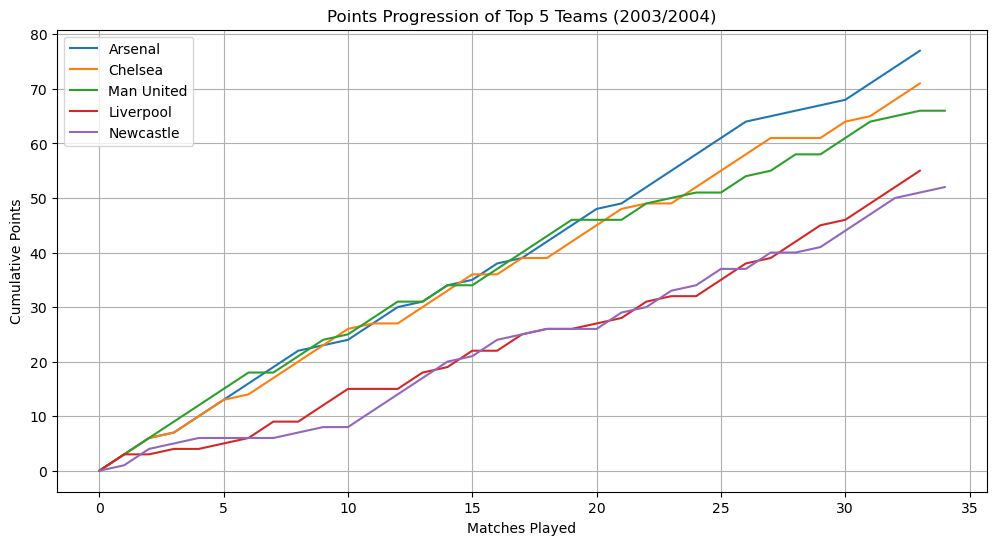

In [22]:
# Get top 5 teams from final league table
# (Assumes 'league_table' is already calculated in previous cell)
top5_teams = league_table.head(5).index.tolist()

# Prepare a DataFrame to track cumulative points for each team after each match
matches = prem.copy()
matches['Date'] = pd.to_datetime(matches['Date'])
matches = matches.sort_values('Date')

# Initialize points progression dict
points_progression = {team: [0] for team in top5_teams}
match_counts = {team: [0] for team in top5_teams}

# Track points after each match for each top 5 team
for i, row in matches.iterrows():
    for team in top5_teams:
        # Copy last value
        points_progression[team].append(points_progression[team][-1])
        match_counts[team].append(match_counts[team][-1])
    # Home team
    if row['HomeTeam'] in top5_teams:
        if row['FTR'] == 'H':
            points_progression[row['HomeTeam']][-1] += 3
        elif row['FTR'] == 'D':
            points_progression[row['HomeTeam']][-1] += 1
        match_counts[row['HomeTeam']][-1] += 1
    # Away team
    if row['AwayTeam'] in top5_teams:
        if row['FTR'] == 'A':
            points_progression[row['AwayTeam']][-1] += 3
        elif row['FTR'] == 'D':
            points_progression[row['AwayTeam']][-1] += 1
        match_counts[row['AwayTeam']][-1] += 1

# Remove the initial zero (for plotting)
for team in top5_teams:
    points_progression[team] = points_progression[team][1:]
    match_counts[team] = match_counts[team][1:]

# Plot
plt.figure(figsize=(12,6))
for team in top5_teams:
    plt.plot(match_counts[team], points_progression[team], label=team)
plt.xlabel('Matches Played')
plt.ylabel('Cumulative Points')
plt.title('Points Progression of Top 5 Teams (2003/2004)')
plt.legend()
plt.grid(True)
plt.show()

### Home vs. Away Performance by Team

Let's compare the points earned at home and away for each team using a grouped bar chart.

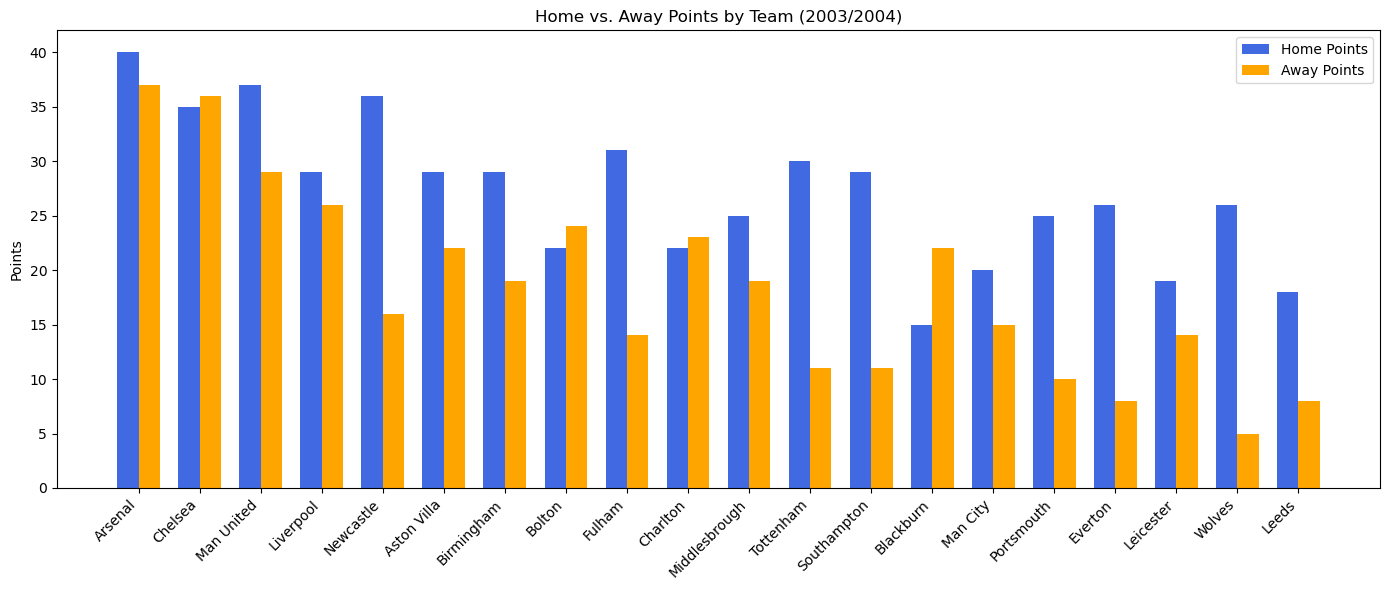

In [20]:
import numpy as np

# Prepare data for plotting
teams = league_table.index.tolist()
home_points = league_table.loc[teams, 'HomePoints']
away_points = league_table.loc[teams, 'AwayPoints']

x = np.arange(len(teams))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(14,6))
rects1 = ax.bar(x - width/2, home_points, width, label='Home Points', color='royalblue')
rects2 = ax.bar(x + width/2, away_points, width, label='Away Points', color='orange')

# Add labels, title, and custom x-axis tick labels
ax.set_ylabel('Points')
ax.set_title('Home vs. Away Points by Team (2003/2004)')
ax.set_xticks(x)
ax.set_xticklabels(teams, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

### Match Analysis

### Biggest Wins, Most Goals, and Surprising Upsets

This section identifies the biggest wins (by goal margin), matches with the most goals, and highlights some of the most surprising upsets based on league position.

In [24]:
# Biggest wins (by goal margin)
prem['GoalMargin'] = abs(prem['FTHG'] - prem['FTAG'])
biggest_wins = prem.sort_values('GoalMargin', ascending=False).head(5)
print('Biggest Wins (by goal margin):')
display(biggest_wins[['Date','HomeTeam','AwayTeam','FTHG','FTAG','GoalMargin']])

# Most goals in a match
prem['TotalGoals'] = prem['FTHG'] + prem['FTAG']
most_goals = prem.sort_values('TotalGoals', ascending=False).head(5)
print('Matches with Most Goals:')
display(most_goals[['Date','HomeTeam','AwayTeam','FTHG','FTAG','TotalGoals']])

# Most surprising upsets (lowest ranked team beating highest ranked team)
# We'll use final league_table for ranking
team_ranks = {team: rank+1 for rank, team in enumerate(league_table.index)}
def is_upset(row):
    if row['FTR'] == 'H':
        return team_ranks[row['HomeTeam']] > team_ranks[row['AwayTeam']]
    elif row['FTR'] == 'A':
        return team_ranks[row['AwayTeam']] > team_ranks[row['HomeTeam']]
    return False
upsets = prem[prem.apply(is_upset, axis=1)]
# Rank upsets by difference in league position
upsets['RankDiff'] = upsets.apply(lambda row: abs(team_ranks[row['HomeTeam']] - team_ranks[row['AwayTeam']]), axis=1)
most_surprising_upsets = upsets.sort_values('RankDiff', ascending=False).head(5)
print('Most Surprising Upsets (by league position difference):')
display(most_surprising_upsets[['Date','HomeTeam','AwayTeam','FTHG','FTAG','FTR','RankDiff']])

Biggest Wins (by goal margin):


,Date,HomeTeam,AwayTeam,FTHG,FTAG,GoalMargin
223,31/01/04,Leicester,Aston Villa,0,5,5
116,09/11/03,Chelsea,Newcastle,5,0,5
55,20/09/03,Wolves,Chelsea,0,5,5
114,08/11/03,Portsmouth,Leeds,6,1,5
206,11/01/04,Leicester,Chelsea,0,4,4


Matches with Most Goals:


,Date,HomeTeam,AwayTeam,FTHG,FTAG,TotalGoals
286,20/03/04,Middlesbrough,Birmingham,5,3,8
82,18/10/03,Man City,Bolton,6,2,8
257,22/02/04,Tottenham,Leicester,4,4,8
147,06/12/03,Tottenham,Wolves,5,2,7
200,10/01/04,Blackburn,Bolton,3,4,7


Most Surprising Upsets (by league position difference):


C:\Users\laura\AppData\Local\Temp\ipykernel_43852\4066059179.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  upsets['RankDiff'] = upsets.apply(lambda row: abs(team_ranks[row['HomeTeam']] - team_ranks[row['AwayTeam']]), axis=1)


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,RankDiff
214,17/01/04,Wolves,Man United,1,0,H,16
84,18/10/03,Portsmouth,Liverpool,1,0,H,12
275,14/03/04,Man City,Man United,4,1,H,12
159,14/12/03,Leeds,Fulham,3,2,H,11
317,01/05/04,Blackburn,Man United,1,0,H,11


### Visualizing Biggest Wins, Most Goals, and Surprising Upsets

The following visualizations show the biggest wins (goal margin), matches with the most goals, and the most surprising upsets (by league position difference).

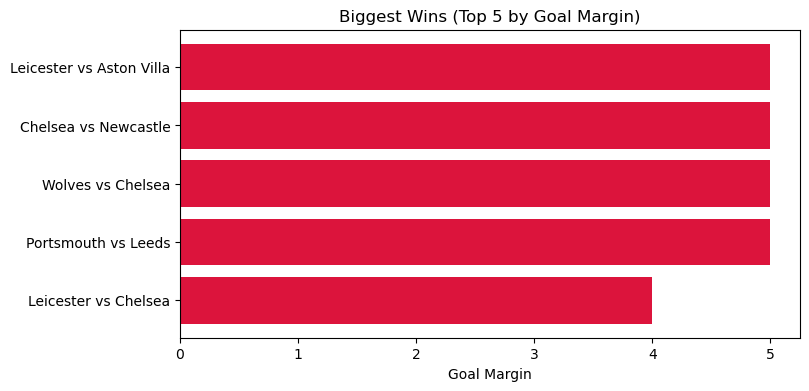

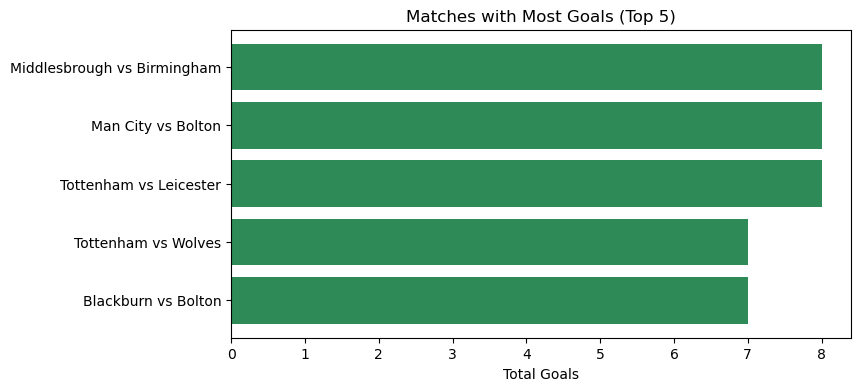

In [26]:
# Bar plot for biggest wins
plt.figure(figsize=(8,4))
plt.barh(biggest_wins['HomeTeam'] + ' vs ' + biggest_wins['AwayTeam'], biggest_wins['GoalMargin'], color='crimson')
plt.xlabel('Goal Margin')
plt.title('Biggest Wins (Top 5 by Goal Margin)')
plt.gca().invert_yaxis()
plt.show()

# Bar plot for most goals in a match
plt.figure(figsize=(8,4))
plt.barh(most_goals['HomeTeam'] + ' vs ' + most_goals['AwayTeam'], most_goals['TotalGoals'], color='seagreen')
plt.xlabel('Total Goals')
plt.title('Matches with Most Goals (Top 5)')
plt.gca().invert_yaxis()
plt.show()

